# 07 — Advanced Evaluation of Tuned Candidates

## 1. Objective
The goal of this notebook is to perform a deep, multi-dimensional evaluation of the two Phase 6 tuned candidate models:
1. **Tuned Logistic Regression** (`C=0.1, solver=lbfgs, max_iter=1000`)
2. **Tuned Support Vector Machine** (`C=100, kernel=linear, gamma=scale, probability=True`)

### Scope & Methodological Rules:
1. **Evaluation Focus Only:** No final model selection is performed in this phase.
2. **Untouched Test Set:** Test metrics (Confusion Matrix, ROC Curves, Precision-Recall Curves) are evaluated on the held-out test set ($N=184$).
3. **Training-Only Threshold & Calibration:** Decision threshold trade-off analysis ($0.10$ to $0.90$) and probability calibration (Brier scores & reliability diagrams) are computed strictly on training data ($N=734$) using 5-fold Out-of-Fold (OoF) predictions via `cross_val_predict`.
4. **No Model Persistence:** `models/` directory remains completely empty.


## 2. Load Project Modules & Tuned Candidate Models
We load dataset utilities and initialize the tuned candidate model configurations.


In [1]:
import sys
from pathlib import Path

# Locate project root containing src/
root_dir = Path.cwd()
for p in [root_dir] + list(root_dir.parents):
    if (p / 'src' / 'config.py').exists():
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
        break

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from src.config import REPORTS_DIR, FIGURES_DIR, RANDOM_STATE
from src.data_loader import load_model_data, split_data
from src.advanced_evaluation import (
    get_tuned_candidate_models,
    evaluate_tuned_confusion_matrices,
    plot_tuned_roc_curves,
    plot_tuned_precision_recall_curves,
    analyze_threshold_tradeoffs,
    analyze_probability_calibration,
    generate_advanced_evaluation_summary,
    run_advanced_evaluation,
)

# Load data and prepare 80/20 train/test split
X, y = load_model_data()
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.20, random_state=RANDOM_STATE)

candidates = get_tuned_candidate_models()
for name, model in candidates.items():
    print(f"Candidate: {name}")
    print(f"  Estimator: {model}\n")


Candidate: Tuned Logistic Regression
  Estimator: LogisticRegression(C=0.1, max_iter=1000, random_state=42)

Candidate: Tuned Support Vector Machine
  Estimator: SVC(C=100, kernel='linear', probability=True, random_state=42)



## 3. Confusion Matrix & Diagnostic Error Analysis
Evaluate confusion matrix counts (TN, FP, FN, TP), Sensitivity, Specificity, FPR, FNR, and F1 score on the held-out test set ($N=184$).


=== Tuned Candidate Confusion Matrix Statistics ===


,Model,TN,FP,FN,TP,Sensitivity,Specificity,False_Positive_Rate,False_Negative_Rate,F1
0,Tuned Logistic Regression,64,18,14,88,0.862745,0.780488,0.219512,0.137255,0.846154
1,Tuned Support Vector Machine,67,15,13,89,0.872549,0.817073,0.182927,0.127451,0.864078


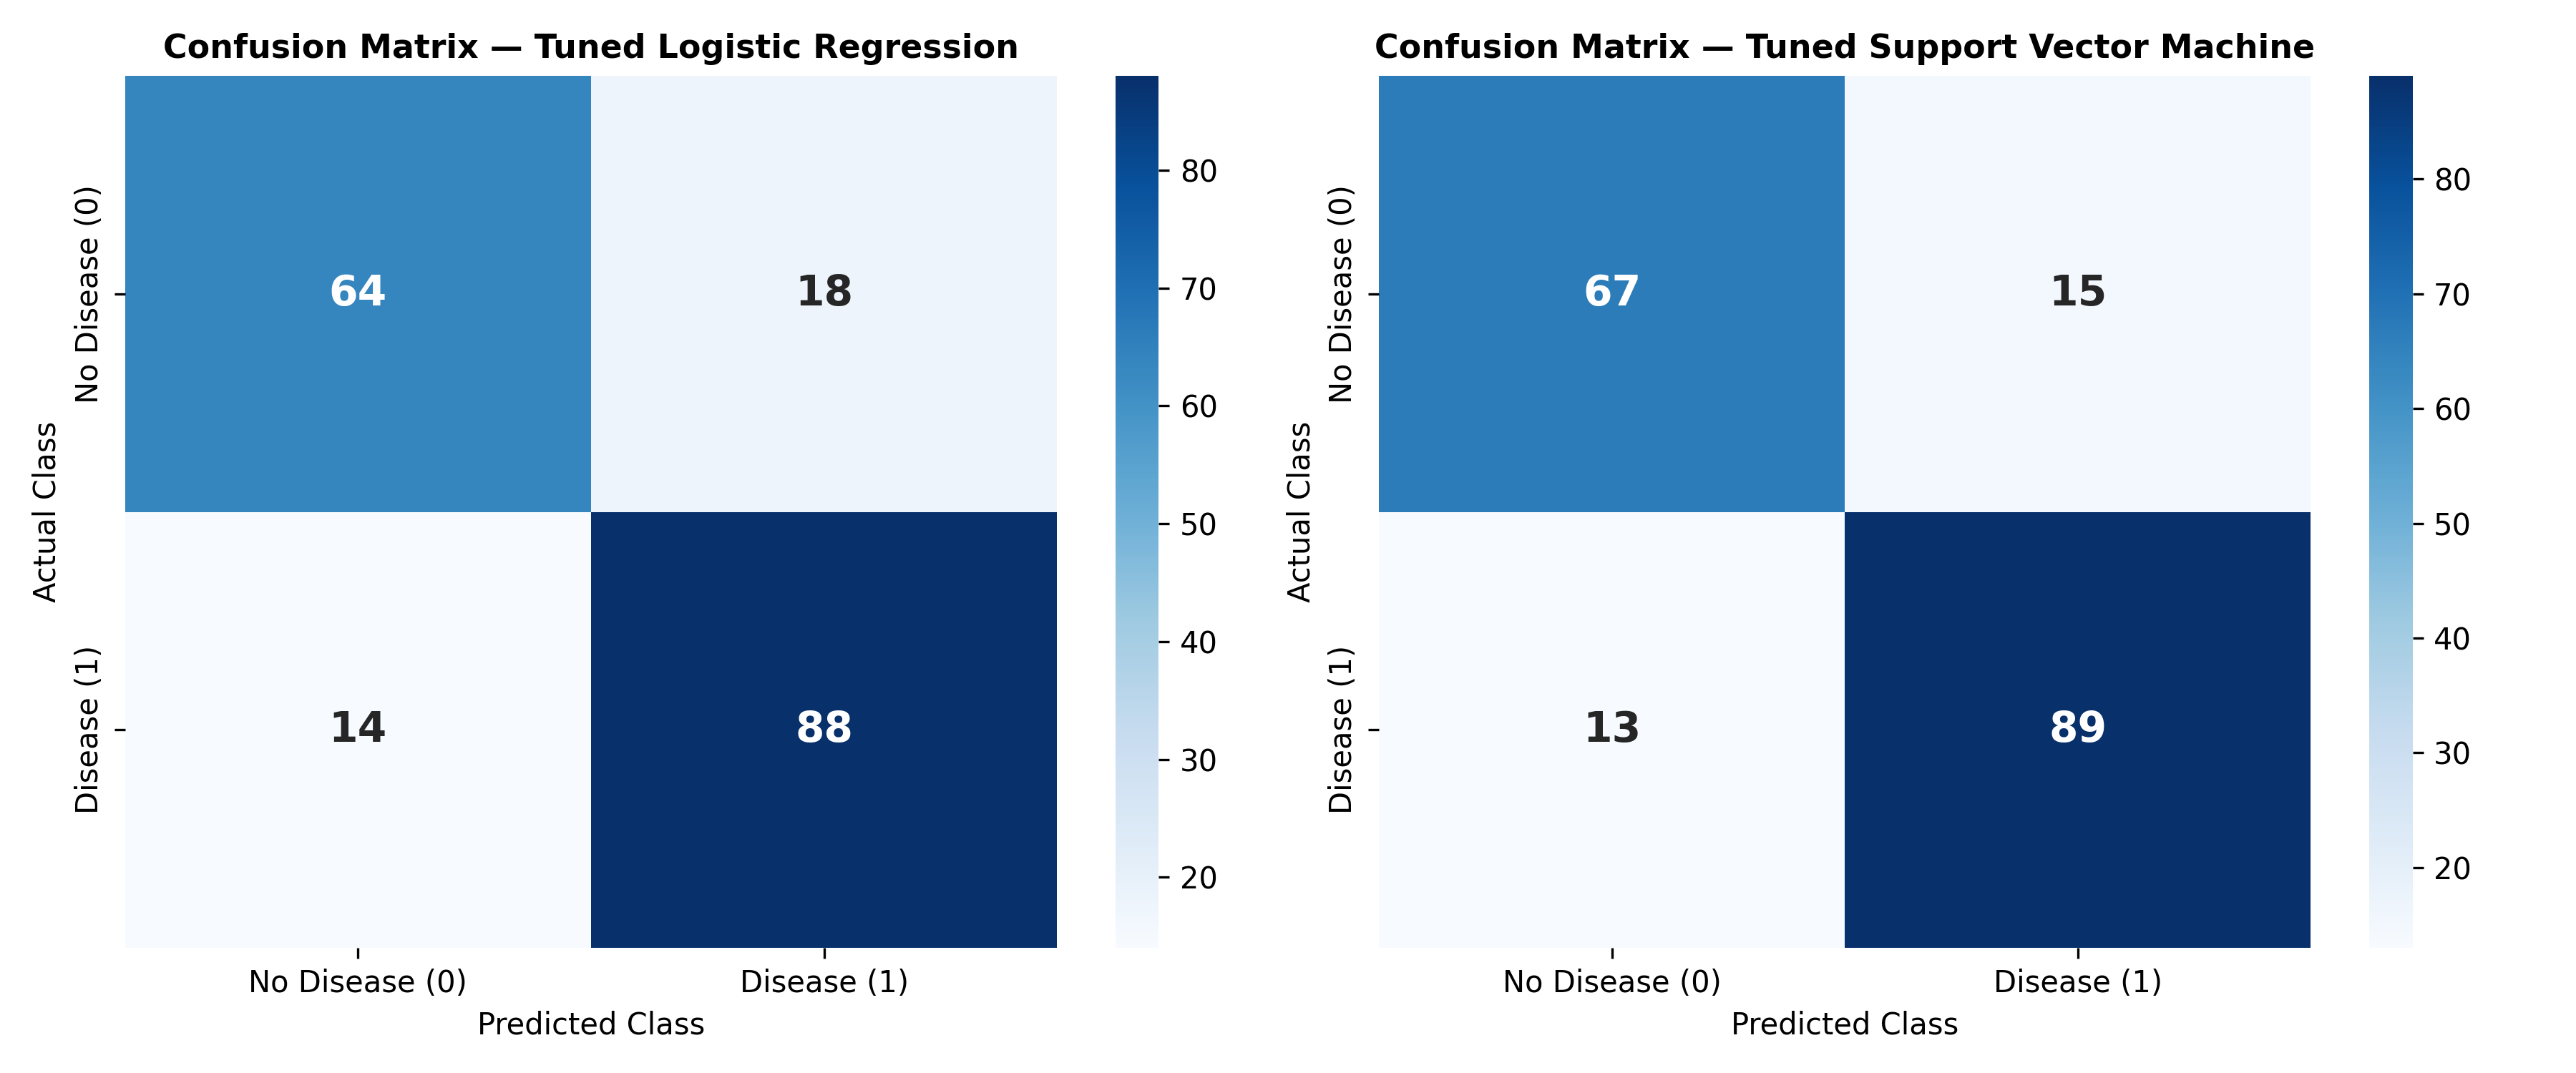

In [2]:
cm_df, fitted_pipelines = evaluate_tuned_confusion_matrices(X_train, X_test, y_train, y_test)
print("=== Tuned Candidate Confusion Matrix Statistics ===")
display(cm_df[["Model", "TN", "FP", "FN", "TP", "Sensitivity", "Specificity", "False_Positive_Rate", "False_Negative_Rate", "F1"]])

cm_fig_path = FIGURES_DIR / "tuned_confusion_matrices.png"
if cm_fig_path.exists():
    display(Image(filename=str(cm_fig_path)))


## 4. Receiver Operating Characteristic (ROC) Discrimination
Generate ROC curves and evaluate ROC-AUC discrimination scores on the held-out test set.


Tuned Logistic Regression Test ROC-AUC: 0.9273
Tuned Support Vector Machine Test ROC-AUC: 0.9295


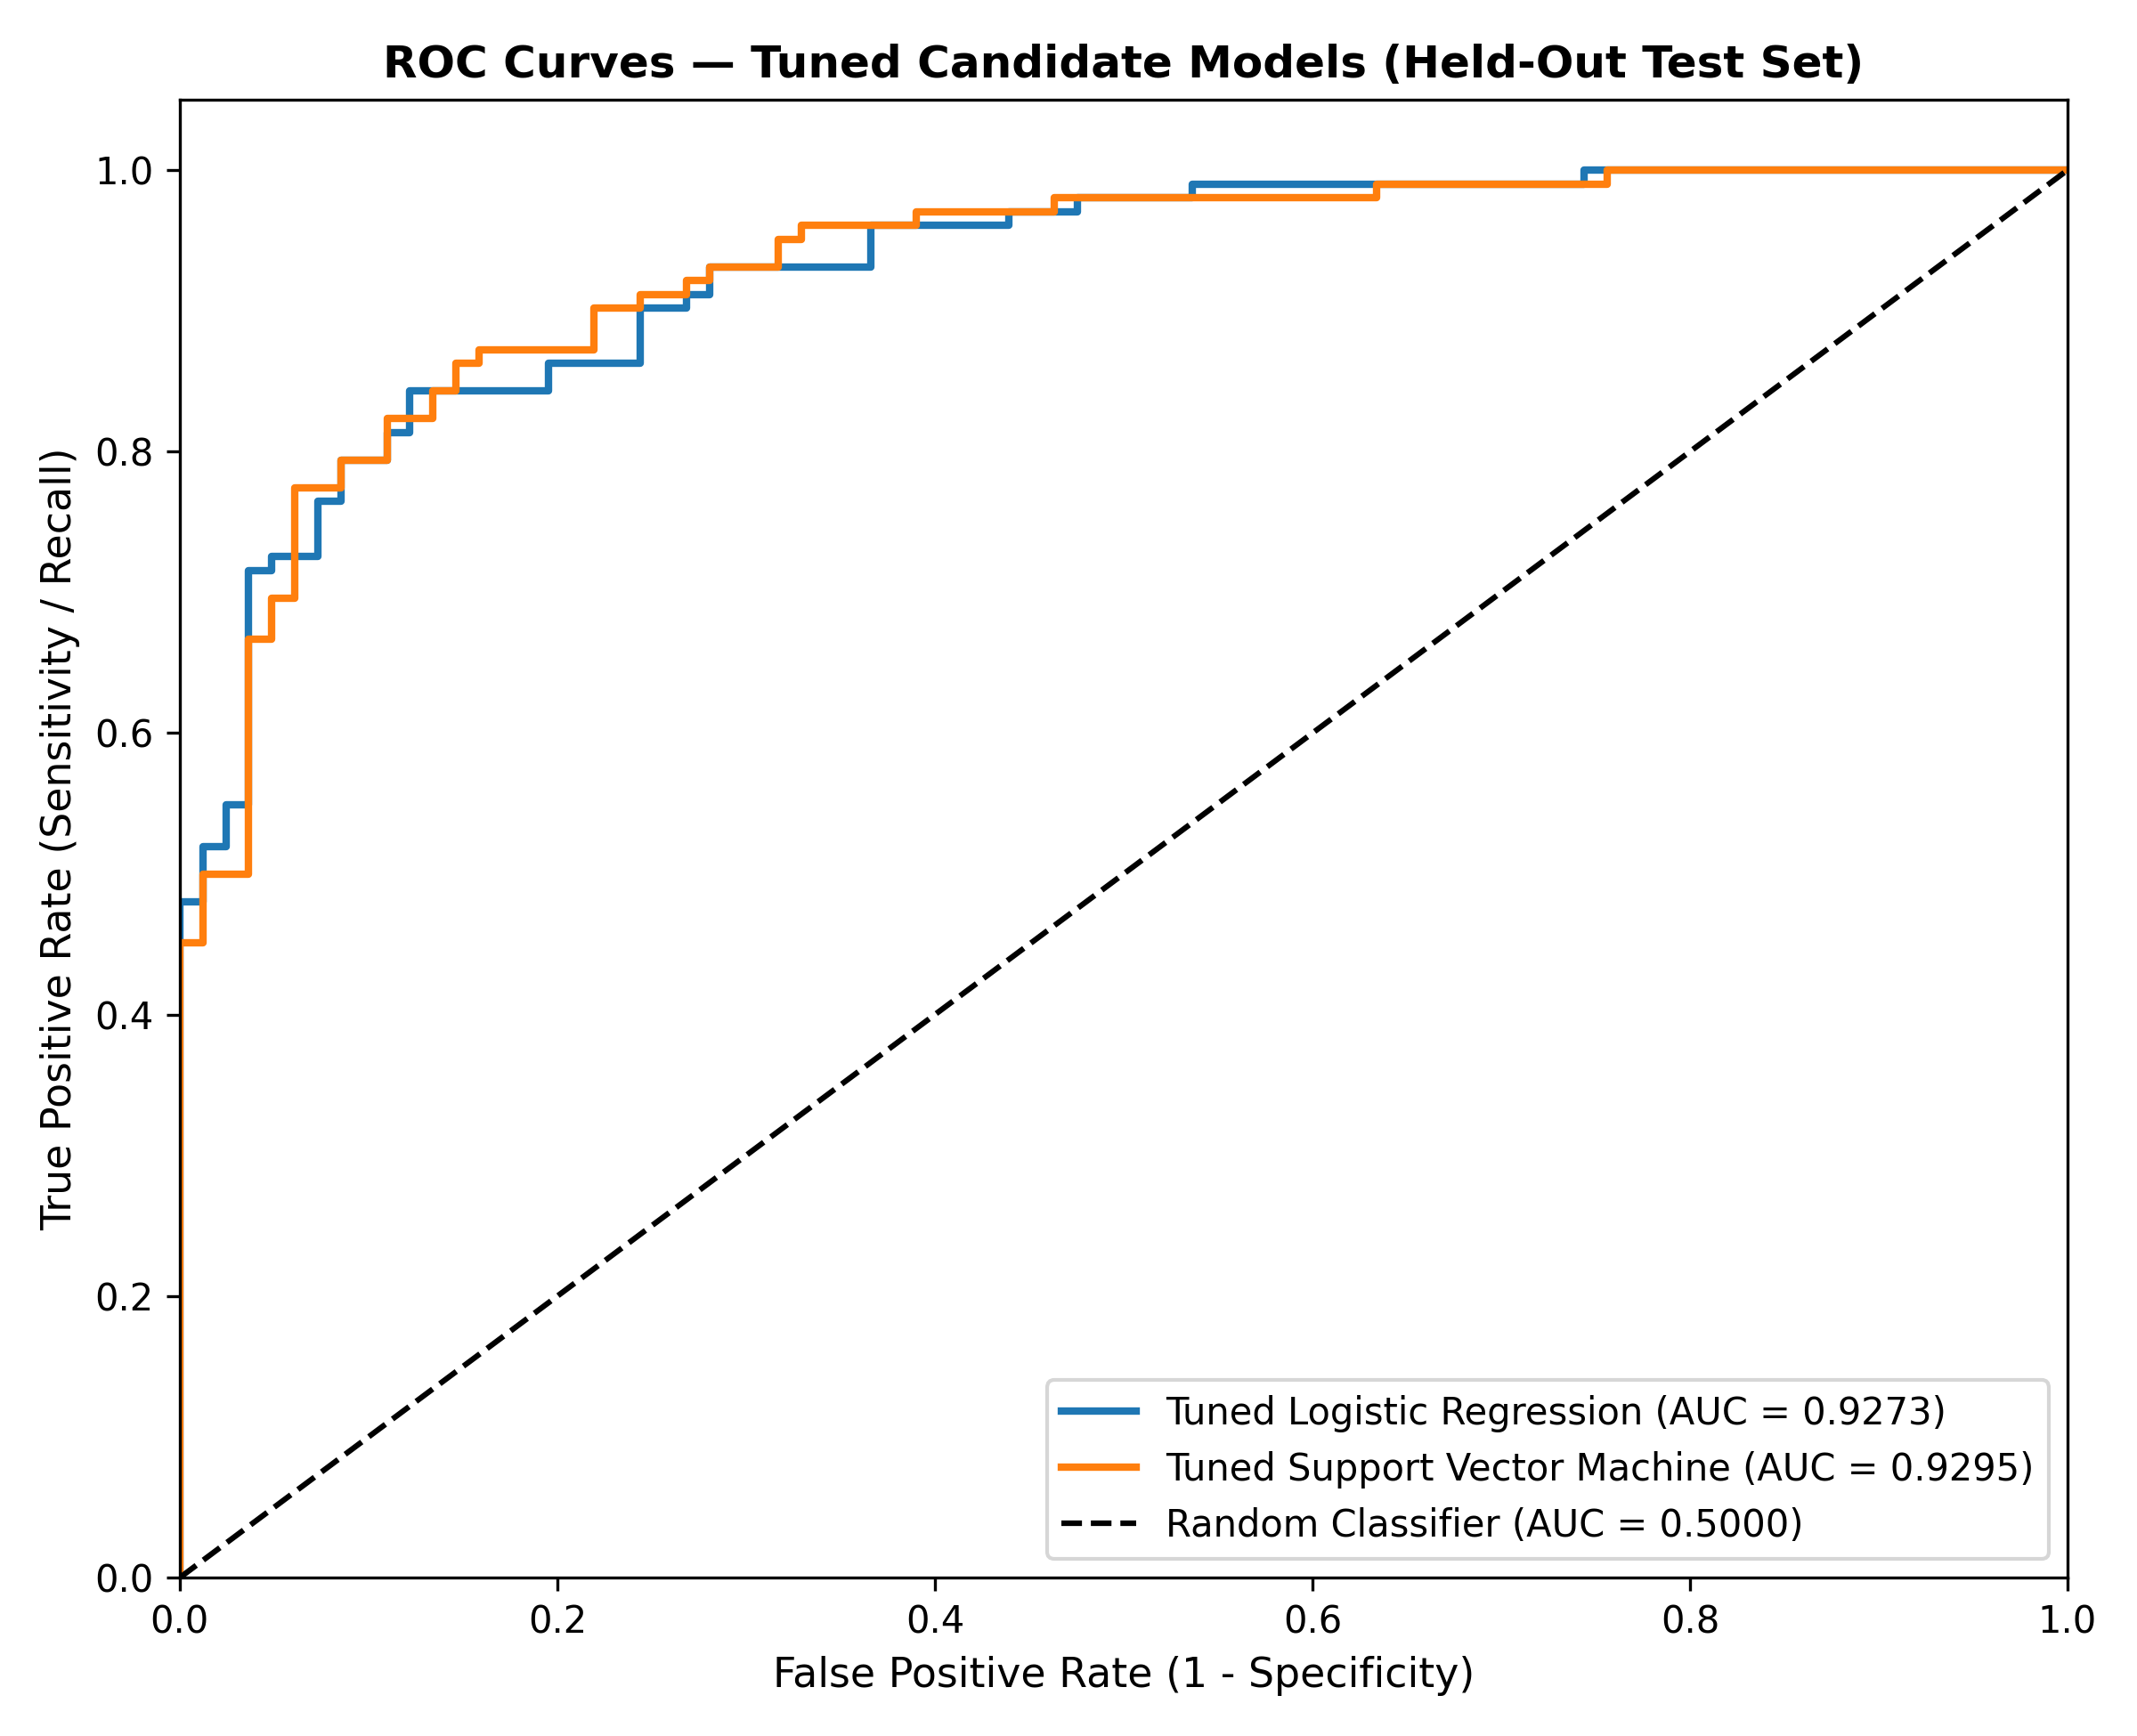

In [3]:
roc_scores = plot_tuned_roc_curves(fitted_pipelines, X_test, y_test)
for name, auc in roc_scores.items():
    print(f"{name} Test ROC-AUC: {auc:.4f}")

roc_fig_path = FIGURES_DIR / "tuned_roc_curves.png"
if roc_fig_path.exists():
    display(Image(filename=str(roc_fig_path)))


## 5. Precision-Recall Curves & Average Precision Scores
Analyze Precision-Recall trade-offs and compute Average Precision (AP) scores on the held-out test set.


Tuned Logistic Regression Test Average Precision (AP): 0.9453
Tuned Support Vector Machine Test Average Precision (AP): 0.9455


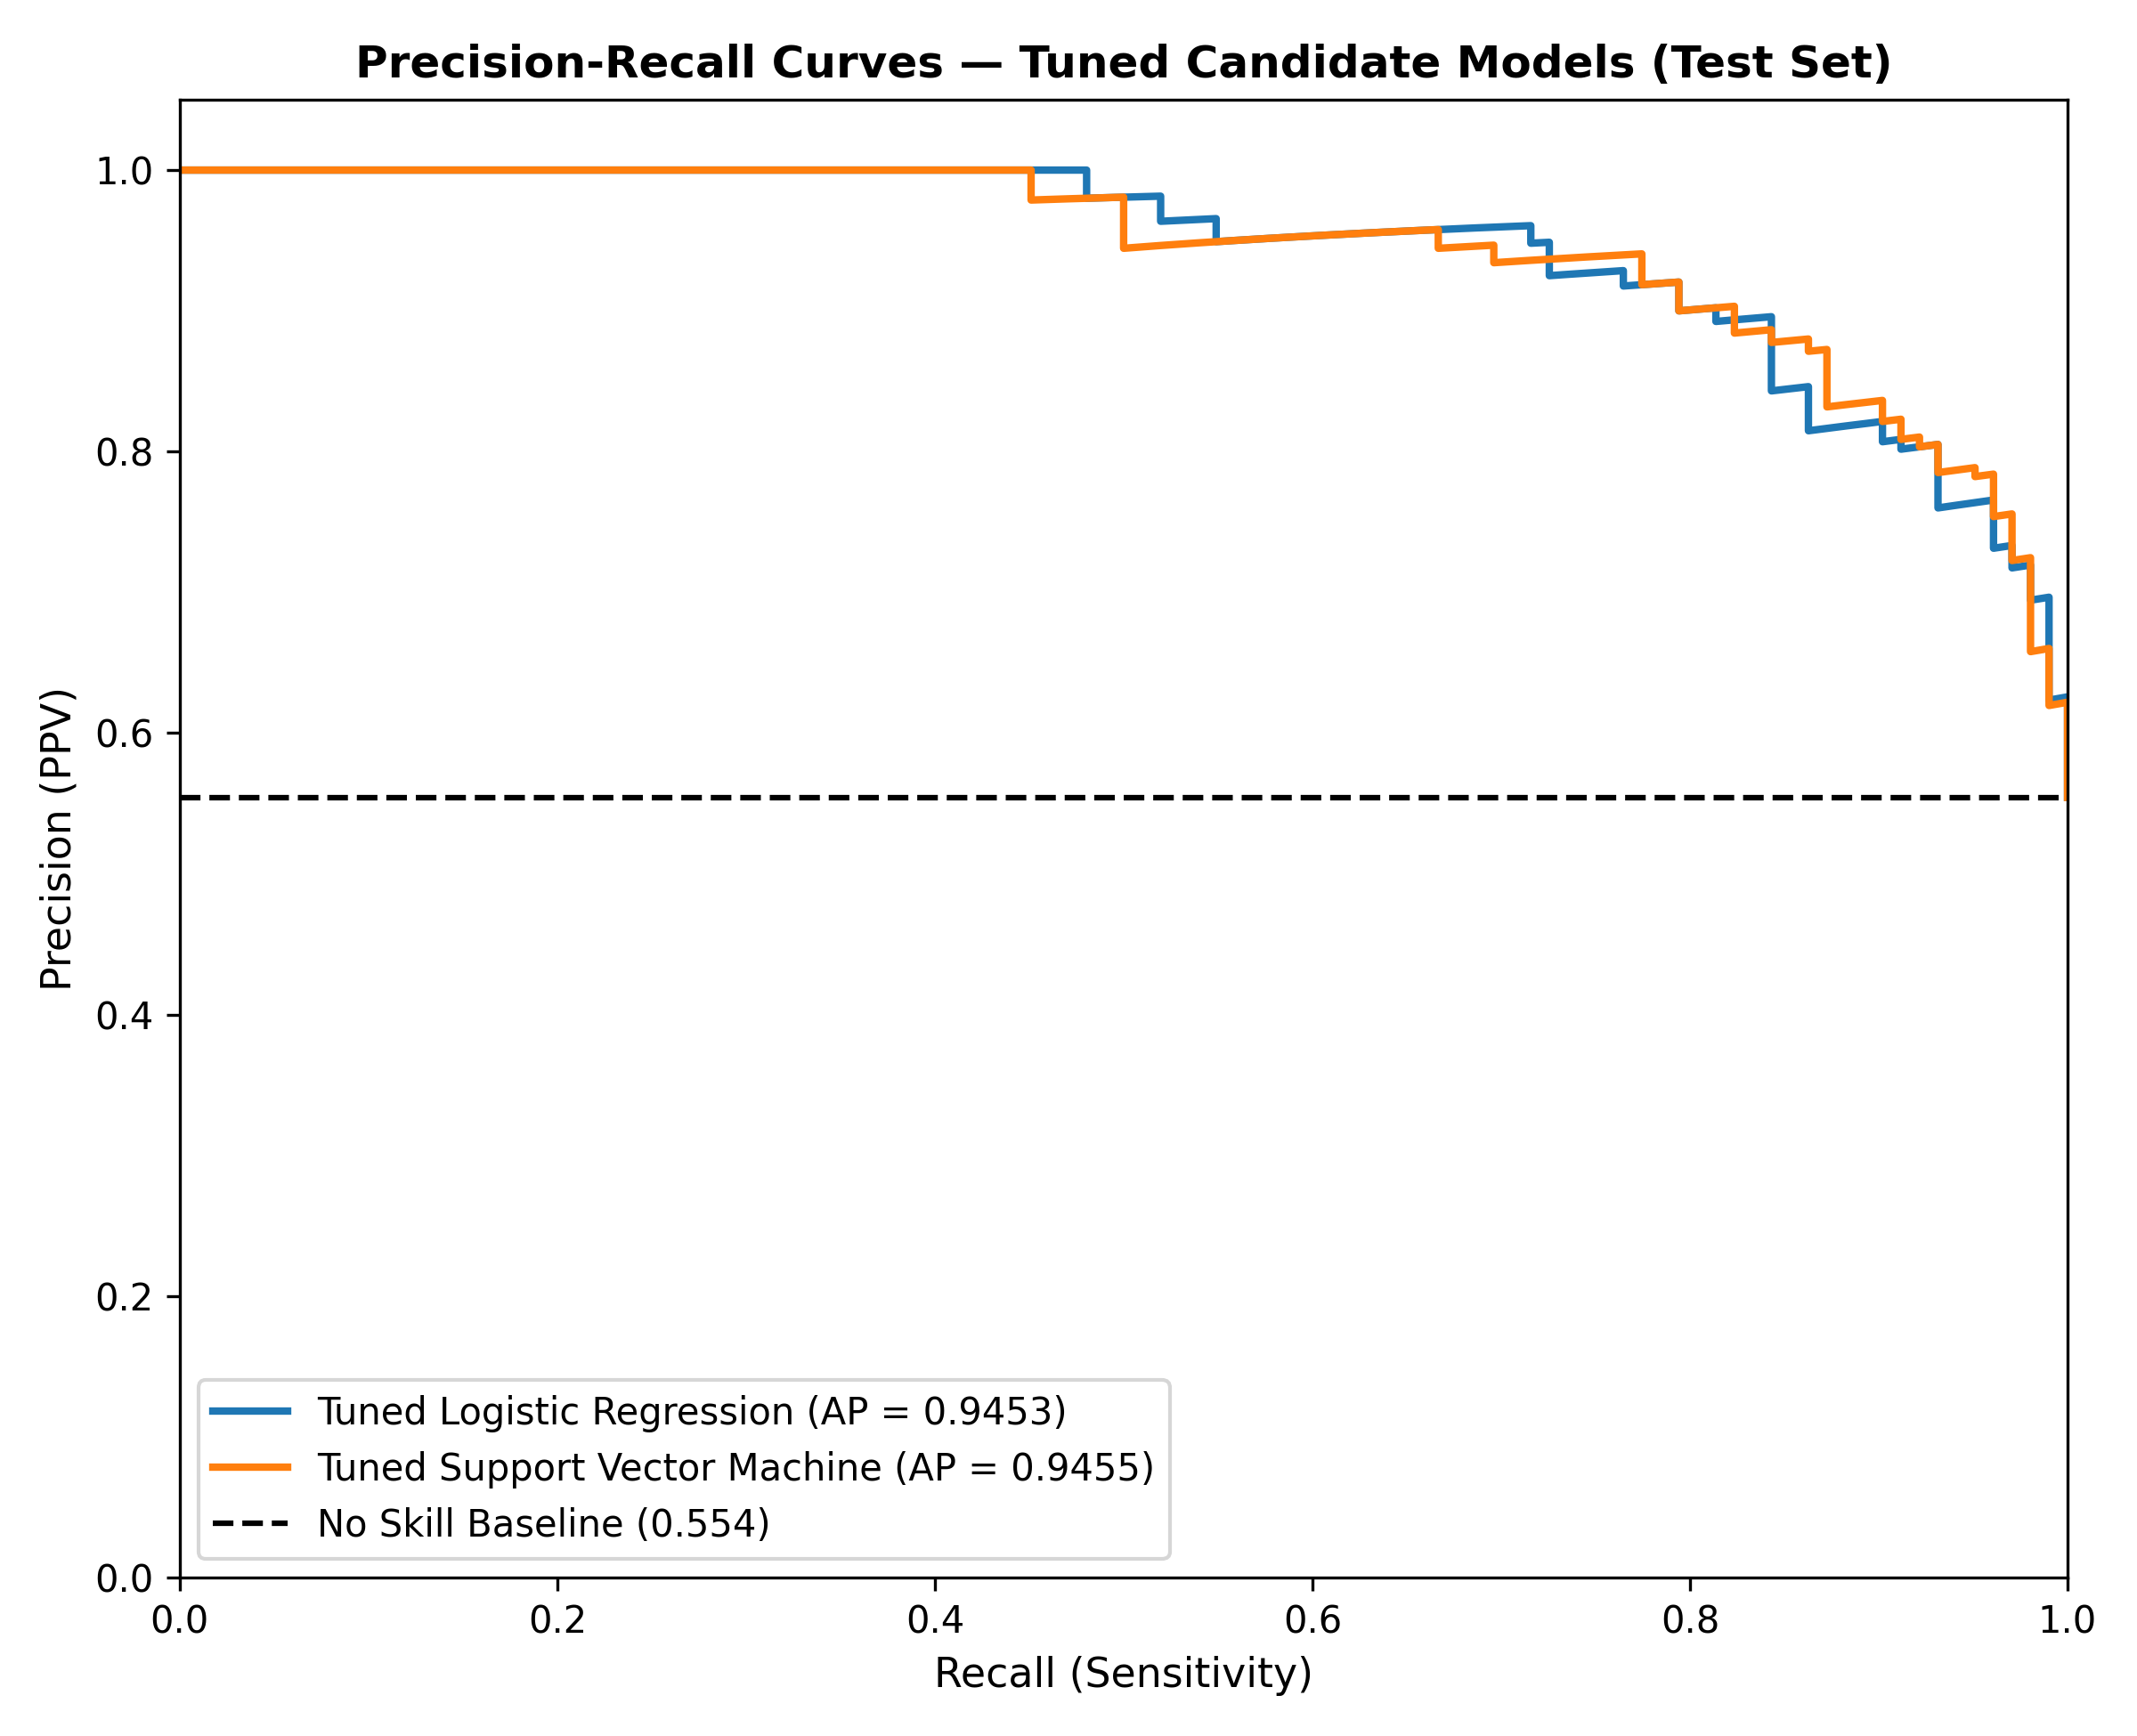

In [4]:
ap_scores = plot_tuned_precision_recall_curves(fitted_pipelines, X_test, y_test)
for name, ap in ap_scores.items():
    print(f"{name} Test Average Precision (AP): {ap:.4f}")

pr_fig_path = FIGURES_DIR / "tuned_precision_recall_curves.png"
if pr_fig_path.exists():
    display(Image(filename=str(pr_fig_path)))


## 6. Training Out-of-Fold Decision Threshold Analysis
Perform decision threshold analysis ($0.10$ to $0.90$) using 5-fold Out-of-Fold (OoF) predicted probabilities on `X_train` ONLY.


=== Threshold Analysis (Sample Table for Tuned Logistic Regression) ===


,Threshold,Sensitivity,Specificity,Precision,F1,False_Negative_Rate,False_Positive_Rate
0,0.1,0.992611,0.143293,0.589181,0.739450,0.007389,0.856707
1,0.2,0.975369,0.408537,0.671186,0.795181,0.024631,0.591463
2,0.3,0.945813,0.570122,0.731429,0.824919,0.054187,0.429878
3,0.4,0.899015,0.713415,0.795207,0.843931,0.100985,0.286585
4,0.5,0.844828,0.783537,0.828502,0.836585,0.155172,0.216463
5,0.6,0.758621,0.844512,0.857939,0.805229,0.241379,0.155488
6,0.7,0.665025,0.893293,0.885246,0.759494,0.334975,0.106707
7,0.8,0.536946,0.923780,0.897119,0.671803,0.463054,0.076220
8,0.9,0.275862,0.963415,0.903226,0.422642,0.724138,0.036585


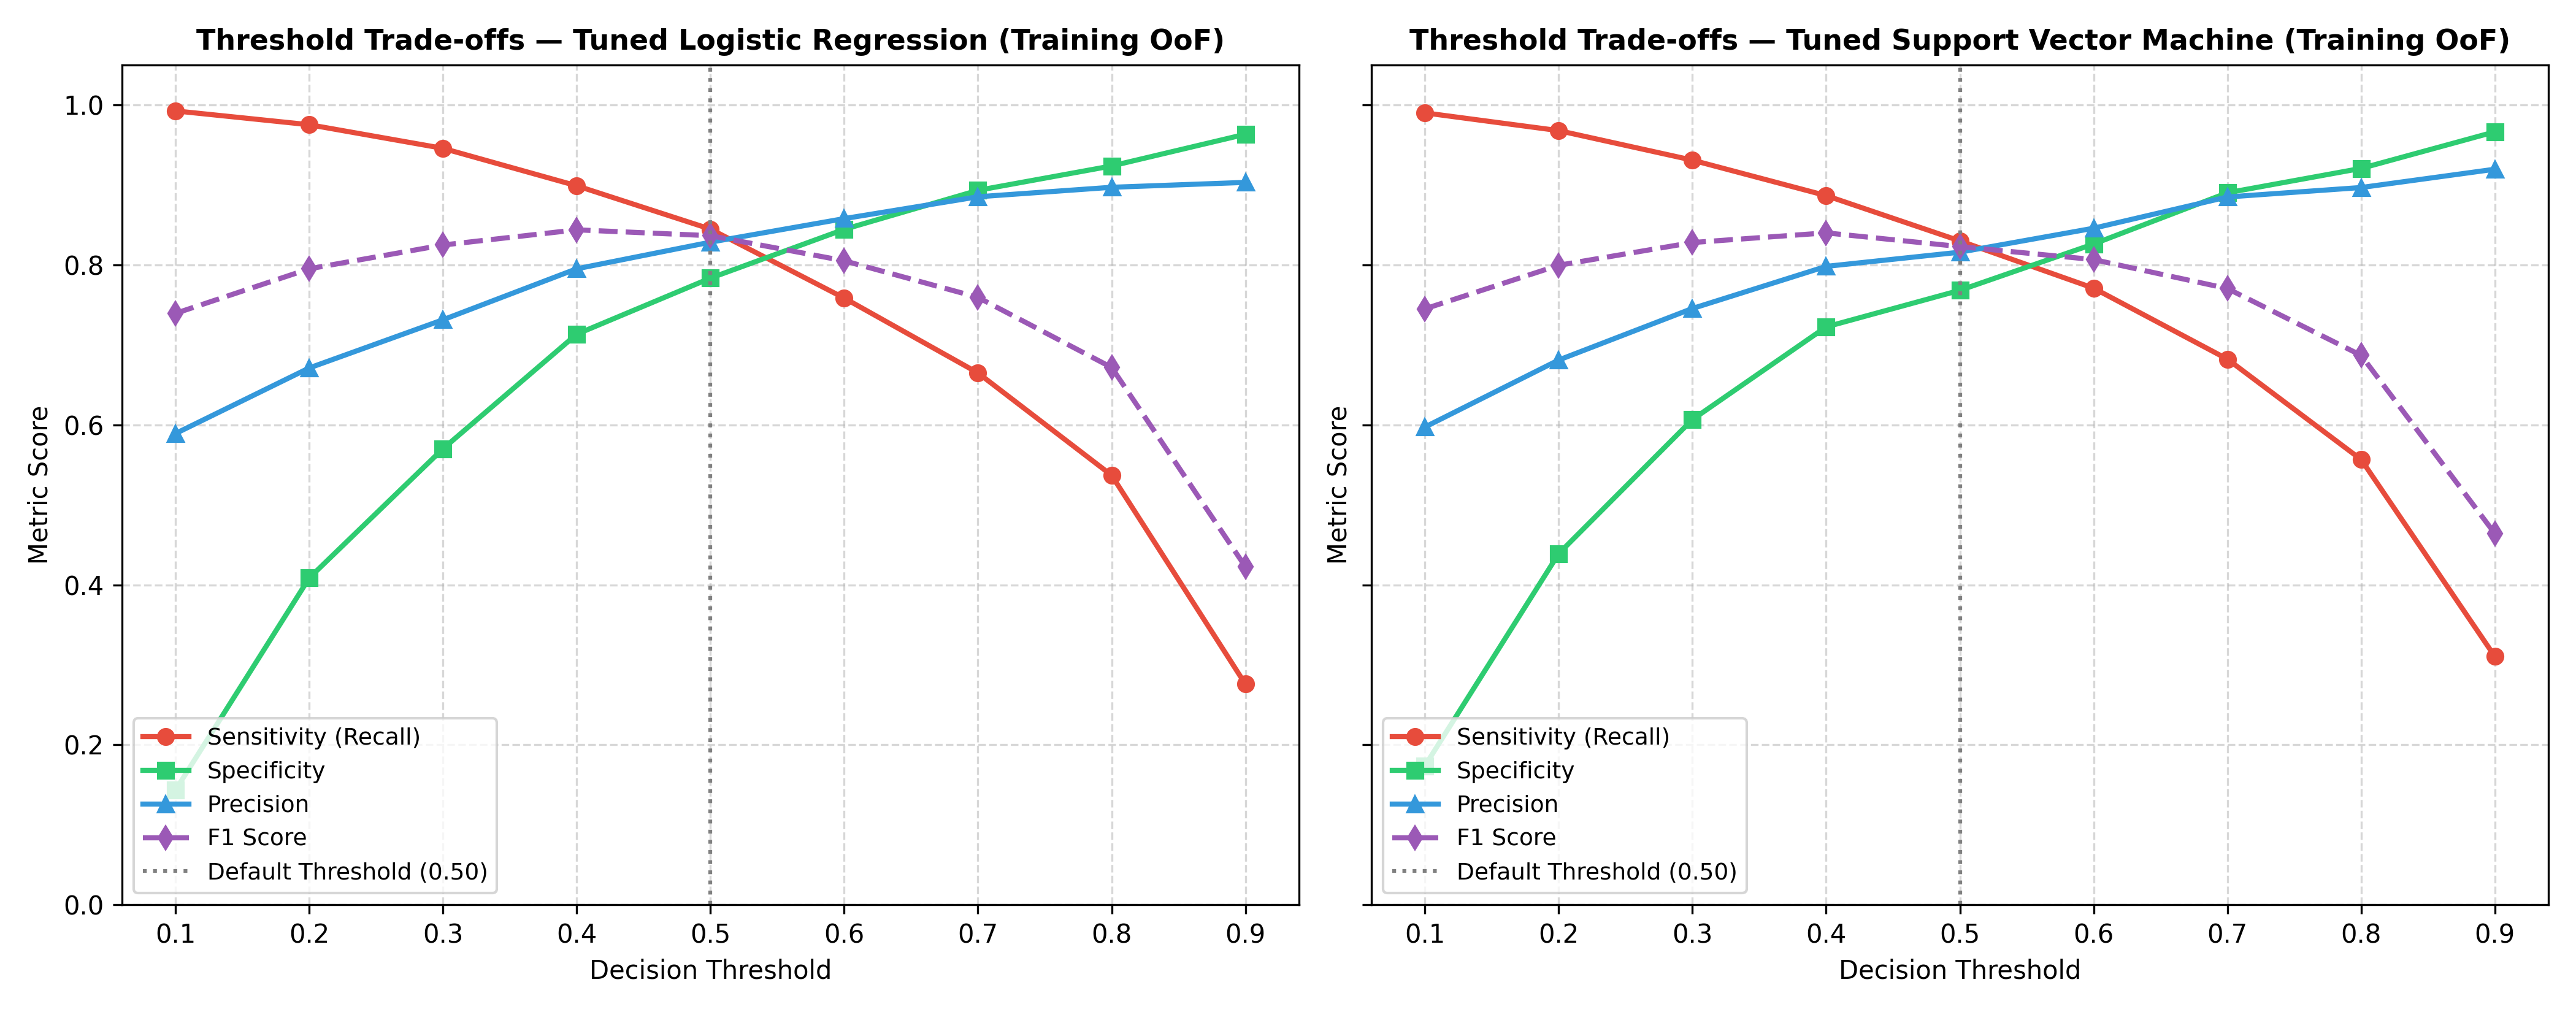

In [5]:
threshold_df, oof_probs = analyze_threshold_tradeoffs(X_train, y_train)
print("=== Threshold Analysis (Sample Table for Tuned Logistic Regression) ===")
display(threshold_df[threshold_df["Model"] == "Tuned Logistic Regression"][["Threshold", "Sensitivity", "Specificity", "Precision", "F1", "False_Negative_Rate", "False_Positive_Rate"]])

thresh_fig_path = FIGURES_DIR / "threshold_tradeoff.png"
if thresh_fig_path.exists():
    display(Image(filename=str(thresh_fig_path)))


## 7. Out-of-Fold Probability Calibration & Brier Scores
Evaluate probability calibration on training Out-of-Fold predictions using Brier scores and reliability curves.

Both models produced Brier scores of approximately 0.14 on training out-of-fold predictions. The calibration curves provide a visual assessment of probability agreement; Brier score alone should not be described as proving strong calibration.


Tuned Logistic Regression OoF Brier Score: 0.1373
Tuned Support Vector Machine OoF Brier Score: 0.1376


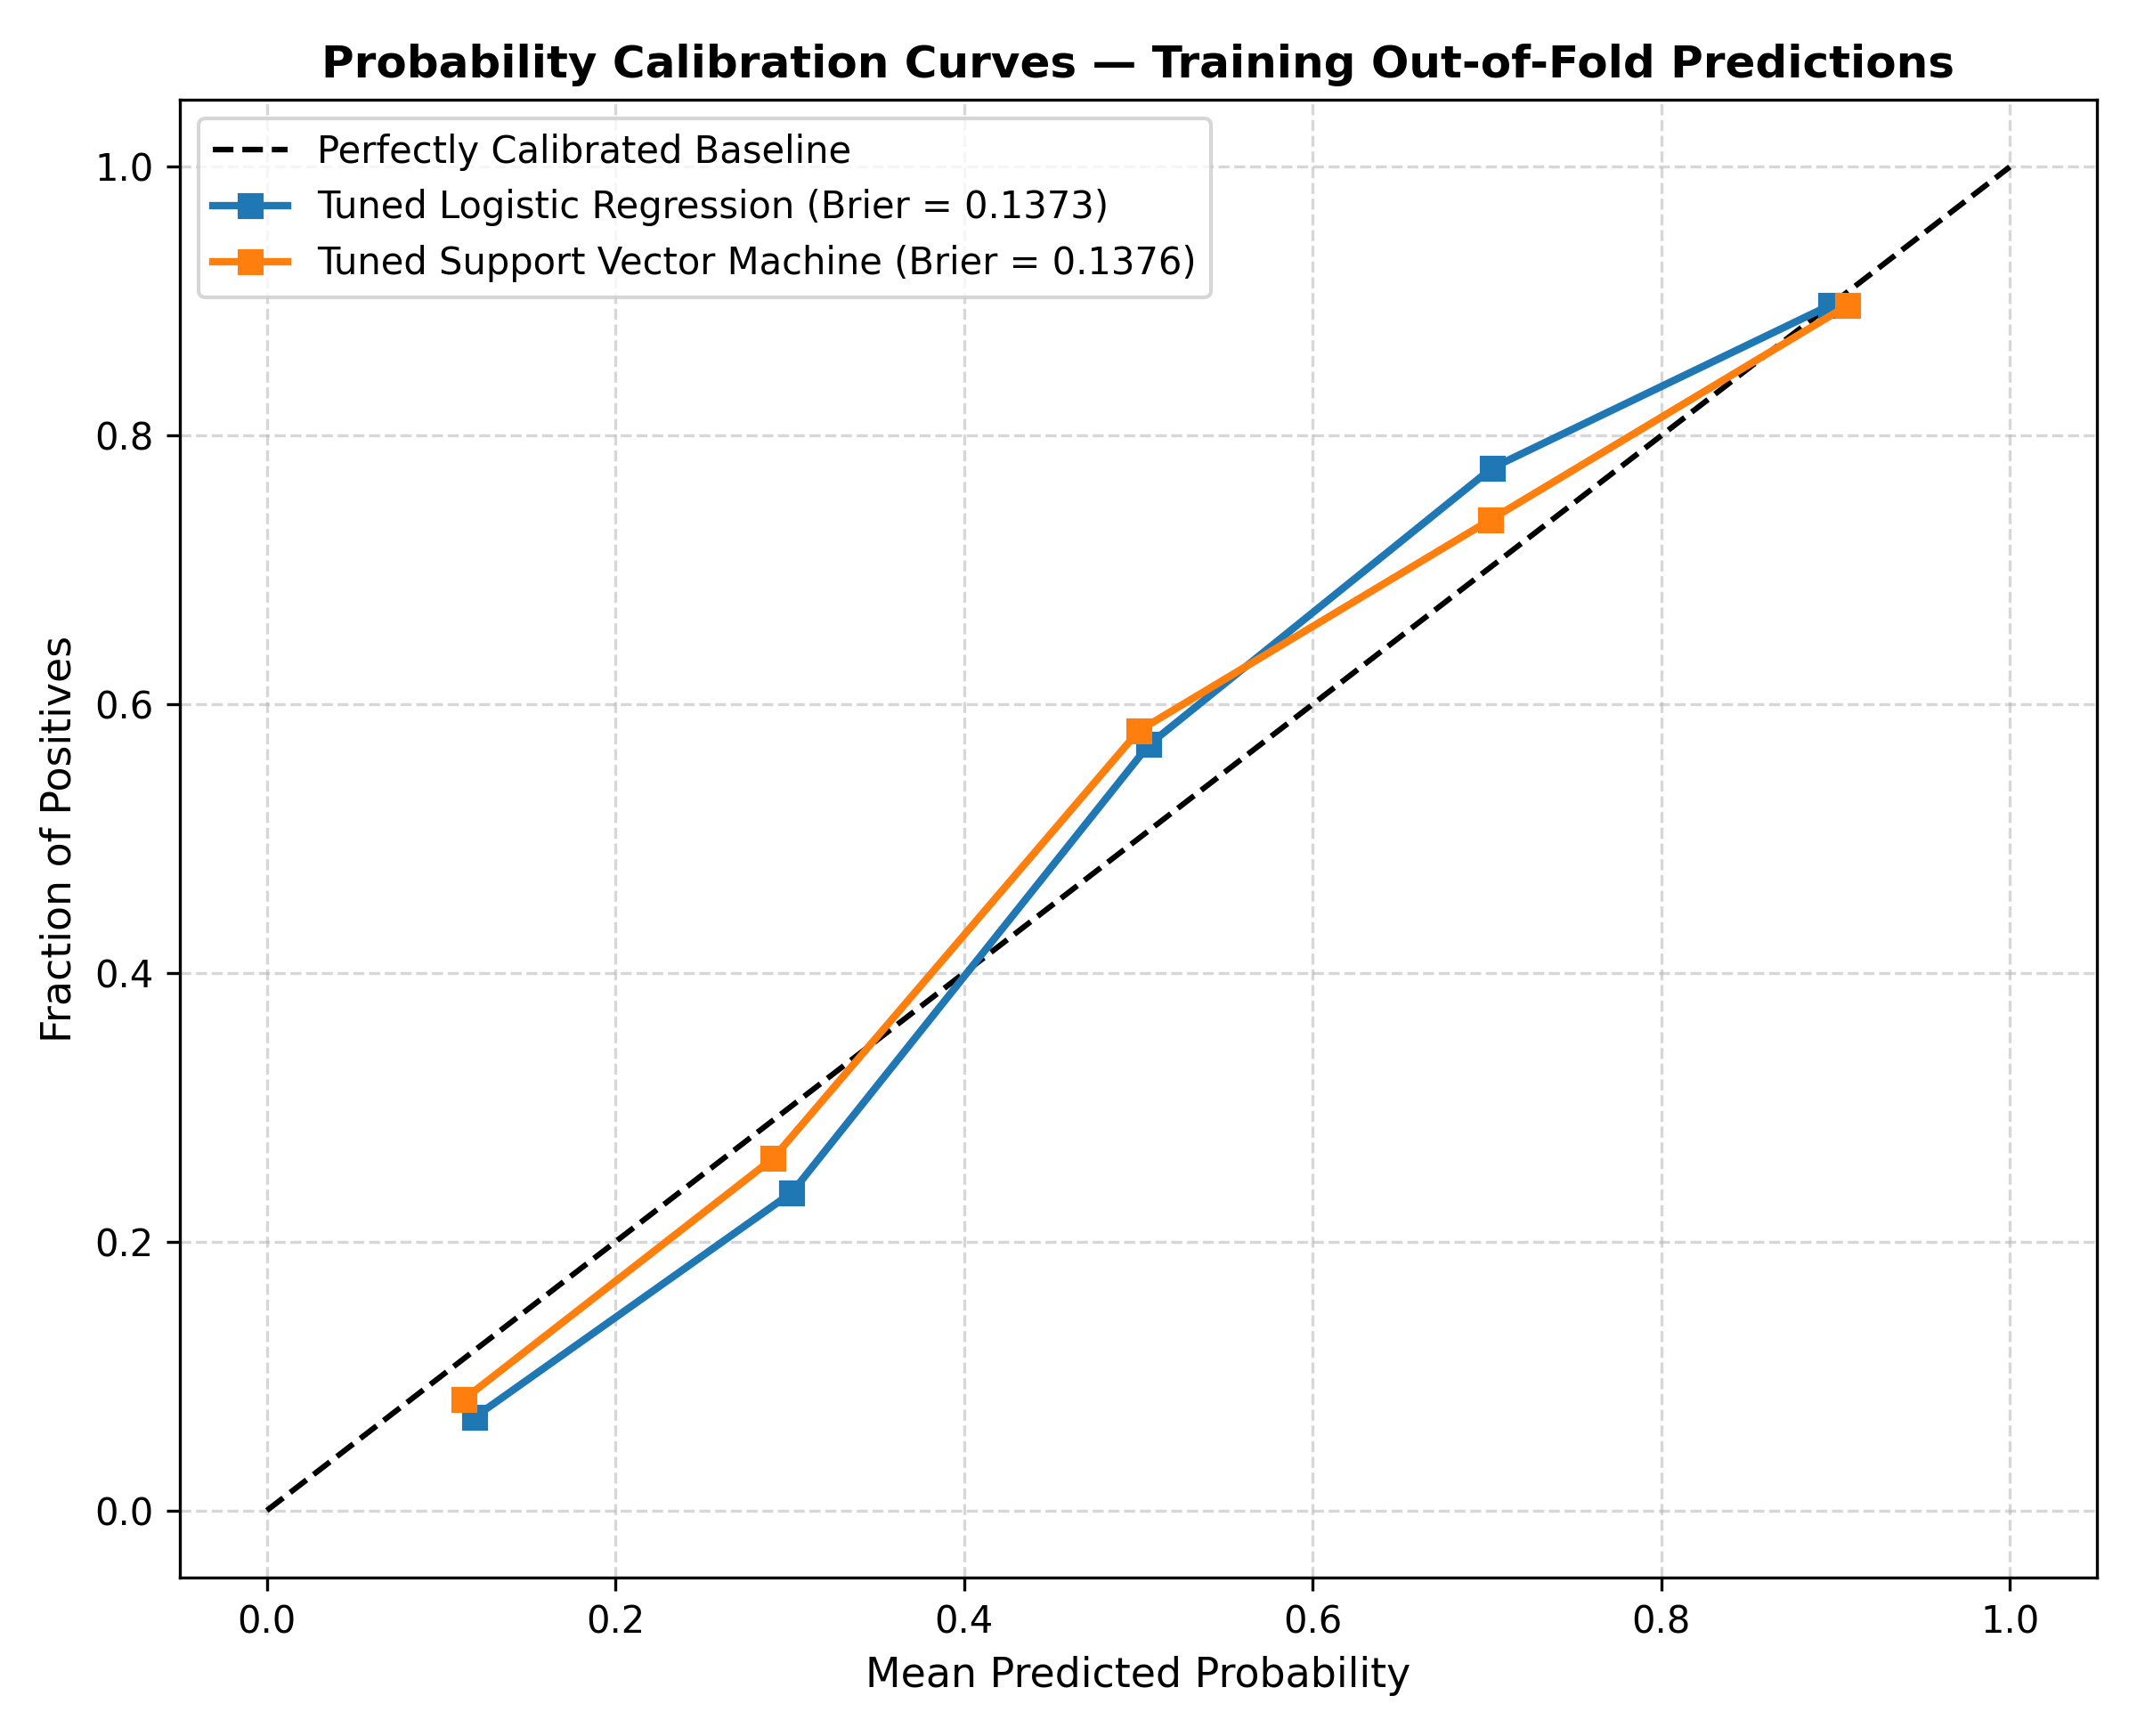

In [6]:
brier_scores = analyze_probability_calibration(X_train, y_train, oof_probs=oof_probs)
for name, brier in brier_scores.items():
    print(f"{name} OoF Brier Score: {brier:.4f}")

calib_fig_path = FIGURES_DIR / "calibration_curves.png"
if calib_fig_path.exists():
    display(Image(filename=str(calib_fig_path)))


## 8. Observed Performance Consistency (CV vs. Test)
Compare cross-validation mean performance on training folds against held-out test set metrics.

The CV and held-out test results provide evidence of comparable observed performance across the evaluation procedures. These comparisons do not by themselves establish generalization stability or absence of overfitting.


In [7]:
adv_summary_df = run_advanced_evaluation(X_train, X_test, y_train, y_test)
print("=== Observed Performance Consistency & Generalization Gaps ===")
display(adv_summary_df[["Model", "CV_ROC_AUC_Mean", "CV_ROC_AUC_Std", "Test_ROC_AUC", "Test_Accuracy", "Test_Recall", "Test_Specificity", "Brier_Score"]])


=== Observed Performance Consistency & Generalization Gaps ===


,Model,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,Test_ROC_AUC,Test_Accuracy,Test_Recall,Test_Specificity,Brier_Score
0,Tuned Logistic Regression,0.879513,0.046341,0.927308,0.826087,0.862745,0.780488,0.137263
1,Tuned Support Vector Machine,0.879872,0.044217,0.929460,0.847826,0.872549,0.817073,0.137632


## 9. Comprehensive Candidate Comparison Table
Summary of all evaluation metrics compiled in `reports/advanced_evaluation_summary.csv`.


In [8]:
summary_csv_path = REPORTS_DIR / "advanced_evaluation_summary.csv"
if summary_csv_path.exists():
    full_summary_df = pd.read_csv(summary_csv_path)
    display(full_summary_df)


,Model,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,Test_ROC_AUC,Test_Accuracy,Test_Precision,Test_Recall,Test_Specificity,Test_F1,Test_FPR,Test_FNR,Average_Precision,Brier_Score
0,Tuned Logistic Regression,0.879513,0.046341,0.927308,0.826087,0.830189,0.862745,0.780488,0.846154,0.219512,0.137255,0.945282,0.137263
1,Tuned Support Vector Machine,0.879872,0.044217,0.929460,0.847826,0.855769,0.872549,0.817073,0.864078,0.182927,0.127451,0.945498,0.137632


## 10. Methodological & Scope Limitations

> **CAUTIOUS METHODOLOGICAL SCOPE & NON-CLINICAL NOTICE:**
> 1. **No Final Model Selection:** This phase evaluates error characteristics without declaring a final production model.
> 2. **Non-Clinical Application:** Statistical metrics evaluated on tabular observations do NOT establish medical diagnostic accuracy, efficacy, safety, or clinical utility.
> 3. **Non-Causal Interpretability:** Model output probabilities describe statistical associations within the transformed feature space and do NOT imply causal biological relationships.
> 4. **Threshold Selection Rule:** Any custom threshold tuning must be locked via training-only cross-validation before deployment.
> 5. **Methodological Note on Calibration & Generalization:** Both models produced Brier scores of approximately 0.14 on training out-of-fold predictions. Calibration curves provide a visual assessment of probability agreement; Brier score alone should not be described as proving strong calibration. Likewise, CV and held-out test results provide evidence of comparable observed performance across evaluation procedures, but these comparisons do not by themselves establish generalization stability or absence of overfitting.
